In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# X: m x 2 matrix, X[i,:] is the 2D feature vector of the i-th sample
X = np.array([[1,1.5], 
			  [1.2, 2.5], 
			  [1,3.5], 
			  [2,2.25], 
			  [1.8, 3], 
			  [2.5,4], 
			  [3,1.9], 
	          [1.5, .5], 
	          [2.5, .8], 
	          [2.8, .3], 
	          [3.2, .3], 
	          [3, .8], 
	          [3.8, 1], 
	          [4,2], 
	          [1.8,1.8]])
# y: m-D vector, y[i] is the label of the i-th sample
y = np.append(np.ones((7,)), -np.ones((8,)))
# append a constant 1 to each feature vector, so X is now a m x 3 matrix
X = np.append(X, np.ones((15,1)), axis=1)

# Xy[i,:] = X[i,:] * y[i]
Xy = X * y.reshape((-1,1))

In [34]:

# X.shape = (15,3), Xy.shape = (15, 3), y.shape = (15,)
m = X.shape[0]
print("X[0].shape",X[0].shape)
print("m:",m)
print("X:",X)
print("Xy:",Xy)
print("y:",y)

X[0].shape (3,)
m: 15
X: [[1.   1.5  1.  ]
 [1.2  2.5  1.  ]
 [1.   3.5  1.  ]
 [2.   2.25 1.  ]
 [1.8  3.   1.  ]
 [2.5  4.   1.  ]
 [3.   1.9  1.  ]
 [1.5  0.5  1.  ]
 [2.5  0.8  1.  ]
 [2.8  0.3  1.  ]
 [3.2  0.3  1.  ]
 [3.   0.8  1.  ]
 [3.8  1.   1.  ]
 [4.   2.   1.  ]
 [1.8  1.8  1.  ]]
Xy: [[ 1.    1.5   1.  ]
 [ 1.2   2.5   1.  ]
 [ 1.    3.5   1.  ]
 [ 2.    2.25  1.  ]
 [ 1.8   3.    1.  ]
 [ 2.5   4.    1.  ]
 [ 3.    1.9   1.  ]
 [-1.5  -0.5  -1.  ]
 [-2.5  -0.8  -1.  ]
 [-2.8  -0.3  -1.  ]
 [-3.2  -0.3  -1.  ]
 [-3.   -0.8  -1.  ]
 [-3.8  -1.   -1.  ]
 [-4.   -2.   -1.  ]
 [-1.8  -1.8  -1.  ]]
y: [ 1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1.]


In [35]:
# sigmoid function
def sigmoid(z):
	return 1/(1 + np.exp(-z))

def fp(w):
    grad = 0
    a = 0
    for i in range(m):
        grad -= y[i] * (1 - sigmoid(y[i] * np.matmul(X[i],w))) * X[i].reshape(3,)
    return grad

In [36]:
w0 = np.array([1.0,2.0,3.0])
print(fp(w0))

[22.57967902  7.493467    7.99026082]


In [37]:
# minimize f by gradient descent
w = np.array([1.0,2.0,3.0])
w_traces = []
for i in range(1000000):
    w_grad = fp(w)
    w_traces.append(w.copy())
    if(np.linalg.norm(w_grad, ord = 2) < 1e-4):
        break
    w -= 0.01 * w_grad

print("w",w)

w [-1.4700573   4.44147843 -4.37162527]


In [38]:
# compute the accuracy on the training set
w = w_traces[-1]
y_hat = 2*(X@w > 0)-1

accuracy = sum(y_hat == y) / float(len(y))
print(f"accuracy = {accuracy}")

accuracy = 0.8666666666666667


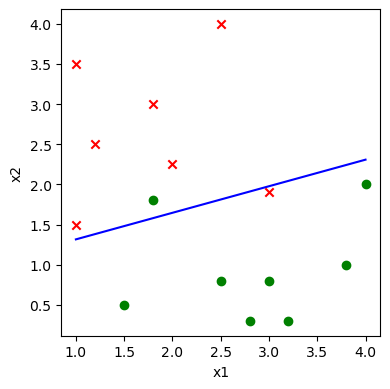

In [41]:
# visualization
plt.figure(figsize=(4, 4))

plt.scatter(*zip(*X[y>0, 0:2]), c='r', marker='x')
plt.scatter(*zip(*X[y<0, 0:2]), c='g', marker='o')

# plot the decision boundary w[0] * x1 + w[1] * x2 + w[0] = 0
x1 = np.array([min(X[:, 0]), max(X[:, 0])])
x2 = -(w[0] * x1 + w[2]) / w[1]
plt.plot(x1, x2, 'b-')

plt.xlabel('x1')
plt.ylabel('x2')

plt.tight_layout()
plt.savefig("figures/T7.png")
plt.show()